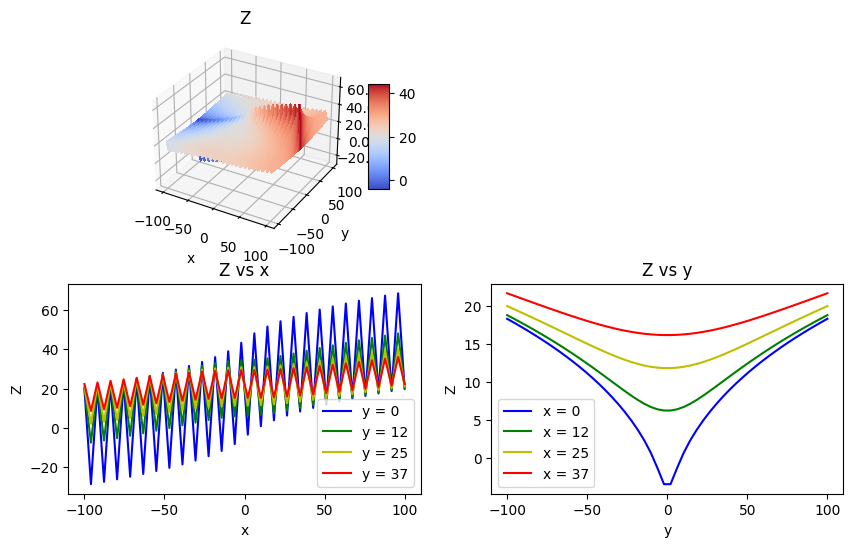

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

'''
Evaluate z by taking advantage of discretized grid rather than integration.
'''

# =========================
# Spacetime Metric
# ========================
# Linearized Schwarzschild
def g_xx(x, y):
    r = np.sqrt(x**2 + y**2)
    return 1 + 2*GM * (x**2 / r**3)
def g_xy(x, y):
    r = np.sqrt(x**2 + y**2)
    return 2*GM * (x*y / r**3)
def g_yy(x, y):
    r = np.sqrt(x**2 + y**2)
    return 1 + 2*GM * (y**2 / r**3)

# =========================
# Embedding PDE
# =========================
def partial_x_Z(x, y):
    return np.sqrt(g_xx(x, y) - 1)
def partial_y_Z(x, y):
    return np.sqrt(g_yy(x, y) - 1)
# sign checker
def sign_condition_check(x, y, sign_parital_x, sign_parital_y):
    condition_met = False
    dz_dr = x * sign_parital_x*partial_x_Z(x, y) + y * sign_parital_y*partial_y_Z(x, y)
    if dz_dr > 0:
        condition_met = True
    return condition_met
def pick_partialx_sign(x_coord, y_coord):
    '''
    picks either the positive or negative solution at each point in space
    '''
    partialx_sign, partialy_sign = 1, 1
    if sign_condition_check(x_coord, y_coord, partialx_sign, partialy_sign):
        return partialx_sign
    else:
        partialx_sign, partialy_sign = -1, 1
        if sign_condition_check(x_coord, y_coord, partialx_sign, partialy_sign):
            return partialx_sign
        else:
            partialx_sign, partialy_sign = 1, -1
            if sign_condition_check(x_coord, y_coord, partialx_sign, partialy_sign):
                return partialx_sign
            else:
                partialx_sign, partialy_sign = -1, -1
                if sign_condition_check(x_coord, y_coord, partialx_sign, partialy_sign):
                    return partialx_sign
                else:
                    print(f'\nERROR\npick_partialx_sign() : NO SIGN PAIR FOUND AT ({x_coord}, {y_coord})\n')
    return None

# ========================
# values for the system
# ========================
GM = 1
x0 = 10
n_steps = 50 # must be even 

# ========================
# Discretize the metric
# ========================
# values
x_start, x_end = -100, 100
y_start, y_end = -100, 100
dx = (x_end - x_start) / (n_steps - 1)
dy = (y_end - y_start) / (n_steps - 1)
# create the grid
x_axis = np.linspace(x_start, x_end, n_steps)
y_axis = np.linspace(y_start, y_end, n_steps)
x_meshed, y_meshed = np.meshgrid(x_axis, y_axis)
r = np.sqrt(x_meshed**2 + y_meshed**2)
# discretize the metric
g_xx_discretized = g_xx(x_meshed, y_meshed)
g_xy_discretized = g_xy(x_meshed, y_meshed)
g_yy_discretized = g_yy(x_meshed, y_meshed)

# ========================
# Evaluate Z(x,y)
# ========================
# initialize Z
z = np.zeros_like(x_meshed)
# evaluate the boundary condition
left_boundary = 2 * np.sqrt(r[0] - GM)
right_boundary = 2 * np.sqrt(r[-1] - GM)
# apply the boundary conditions
z[:, 0] = left_boundary    # for odd  points
z[:, -1] = right_boundary  # for even points
# evaluate z(x,y)
'''y AND x NEEDS TO BE SCALED BY dx AND dy'''
for y in range(n_steps): # even indeces
    for x in range(2, n_steps, 2):
        # print(f'\nEven indeces, Evaluating z at ({x}, {y}), based on ({x-2}, {y})\n')
        sign_partialx = pick_partialx_sign(x, y)
        z[y][x] = 2*dx * sign_partialx*np.sqrt(g_xx_discretized[y][x-1] - 1) + z[y][x-2]
        # z[:, x] = sign_partialx * 2 * dx * np.sqrt(g_xx_discretized[:,x-1] - 1) + z[:,x-2]
for y in range(n_steps): # odd indeces
    for x in range(n_steps-3, 0, -2):
        # print(f'\nOdd indeces, Evaluating z at ({x}, {y}), based on ({x+2}, {y})\n')
        sign_partialx = pick_partialx_sign(x, y)
        z[y][x] = 2*dx * -sign_partialx*np.sqrt(g_xx_discretized[y][x+1] - 1) + z[y][x+2]
        # z[:, x] = sign_partialx * 2 * dx * np.sqrt(g_xx_discretized[:,x+1] - 1) + z[:,x+2]
''' vectrized version
# implement it once for loop is working
z[:,2::2] = 2*dx * pick_partialx_sign(x_meshed[:,2::2], y_meshed[:,2::2])*np.sqrt(g_xx_discretized[:,1:-1:2] - 1) + z[:,:-2:2]
z[:,1:-3:-2] = 2*dx * pick_partialx_sign(x_meshed[:,1:-3:-2], y_meshed[:,1:-3:-2])*np.sqrt(g_xx_discretized[:,0:-2:2] - 1) + z[:,:-1:-2]
'''


# ========================
# Plots
# ========================
# the function
def plot_3d_and_slice(surface, surface_name):
    num_slices = 4

    fig= plt.figure(figsize=(10, 6))
    ax_3d = fig.add_subplot(221, projection='3d')
    ax_slicex = fig.add_subplot(223)
    ax_slicey = fig.add_subplot(224)

    # from matplotlib example (modified)
    surf = ax_3d.plot_surface(x_meshed, y_meshed, surface, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax_3d.zaxis.set_major_formatter('{x:.02f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax_3d.set(xlabel='x', ylabel='y', title=surface_name)
    # ax_3d.set_zlim(bottom=0)

    color = ['b', 'g', 'y' , 'r']
    while len(color) < num_slices:
        color.append['r']
    
    for i in range(num_slices):
         ax_slicex.plot(x_axis, surface[int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'y = {int(100*i/2/num_slices)}')
         ax_slicex.set(xlabel='x', ylabel=surface_name, title=f'{surface_name} vs x')
         ax_slicey.plot(y_axis, surface[:,int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'x = {int(100*i/2/num_slices)}')
         ax_slicey.set(xlabel='y', ylabel=surface_name, title=f'{surface_name} vs y')
    ax_slicex.legend()
    ax_slicey.legend()
    
    plt.tight_layout
    plt.show()
    return None
'''
# plot the metric
plot_3d_and_slice(g_xx_discretized, 'g_xx')
plot_3d_and_slice(g_xy_discretized, 'g_xy')
plot_3d_and_slice(g_yy_discretized, 'g_yy')
'''
# plot Z
plot_3d_and_slice(z, 'Z')

[23.69990348 23.45764412 23.21825276 22.98216239 22.74984304 22.52180318
 22.29859074 22.08079355 21.86903914 21.66399365 21.46635971 21.27687313
 21.09629819 20.92542139 20.76504357 20.61597031 20.47900068 20.35491454
 20.24445854 20.14833119 20.06716779 20.00152539 19.95186891 19.91855884
 19.90184137 19.90184137 19.91855884 19.95186891 20.00152539 20.06716779
 20.14833119 20.24445854 20.35491454 20.47900068 20.61597031 20.76504357
 20.92542139 21.09629819 21.27687313 21.46635971 21.66399365 21.86903914
 22.08079355 22.29859074 22.52180318 22.74984304 22.98216239 23.21825276
 23.45764412 23.69990348]
[23.69990348 23.45764412 23.21825276 22.98216239 22.74984304 22.52180318
 22.29859074 22.08079355 21.86903914 21.66399365 21.46635971 21.27687313
 21.09629819 20.92542139 20.76504357 20.61597031 20.47900068 20.35491454
 20.24445854 20.14833119 20.06716779 20.00152539 19.95186891 19.91855884
 19.90184137 19.90184137 19.91855884 19.95186891 20.00152539 20.06716779
 20.14833119 20.24445854 

"\n# shape of z\nprint(f'\nz.shape = {z.shape}\n')\n\n# values around the boundaries\nprint(f'z[:10, 0] = {z[:10, 0]}')\nprint(f'z[:10, 1] = {z[:10, 1]}')\nprint(f'z[:10, 2] = {z[:10, 2]}')\nprint(f'z[:10, 3] = {z[:10, 3]}')\nprint()\nprint(f'z[:10, -4] = {z[:10, -4]}')\nprint(f'z[:10, -3] = {z[:10, -3]}')\nprint(f'z[:10, -2] = {z[:10, -2]}')\nprint(f'z[:10, -1] = {z[:10, -1]}')\nprint()\nprint(f'z[0, :10] = {z[0, :10]}')\nprint(f'z[1, :10] = {z[1, :10]}')\nprint(f'z[2, :10] = {z[2, :10]}')\nprint(f'z[3, :10] = {z[3, :10]}')\nprint()\nprint(f'z[-4, :10] = {z[-4, :10]}')\nprint(f'z[-3, :10] = {z[-3, :10]}')\nprint(f'z[-2, :10] = {z[-2, :10]}')\nprint(f'z[-1, :10] = {z[-1, :10]}')\n"

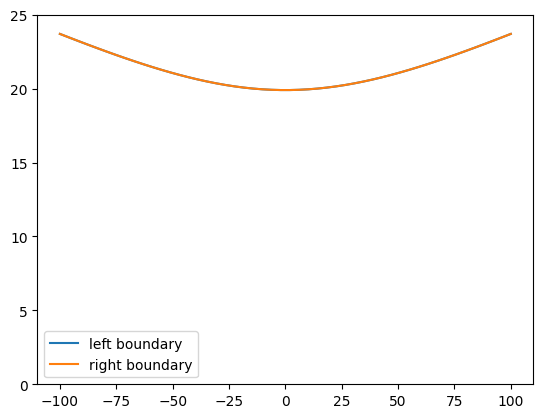

In [8]:
### Value Checks
''' CHECK COMPLETE
# r
plot_3d_and_slice(r, 'r')
'''
# boundary conditions
print(left_boundary)
print(right_boundary)
fig, ax = plt.subplots()
ax.plot(x_axis, z[:,0], label='left boundary')
ax.plot(x_axis, z[:,-1], label='right boundary')
ax.set(ylim=(0,25))
ax.legend()
'''
# shape of z
print(f'\nz.shape = {z.shape}\n')

# values around the boundaries
print(f'z[:10, 0] = {z[:10, 0]}')
print(f'z[:10, 1] = {z[:10, 1]}')
print(f'z[:10, 2] = {z[:10, 2]}')
print(f'z[:10, 3] = {z[:10, 3]}')
print()
print(f'z[:10, -4] = {z[:10, -4]}')
print(f'z[:10, -3] = {z[:10, -3]}')
print(f'z[:10, -2] = {z[:10, -2]}')
print(f'z[:10, -1] = {z[:10, -1]}')
print()
print(f'z[0, :10] = {z[0, :10]}')
print(f'z[1, :10] = {z[1, :10]}')
print(f'z[2, :10] = {z[2, :10]}')
print(f'z[3, :10] = {z[3, :10]}')
print()
print(f'z[-4, :10] = {z[-4, :10]}')
print(f'z[-3, :10] = {z[-3, :10]}')
print(f'z[-2, :10] = {z[-2, :10]}')
print(f'z[-1, :10] = {z[-1, :10]}')
'''

In [4]:
''' TEST pick_partialx_sign() '''
x_test, y_test = 10 , 0
sign = pick_partialx_sign(x_test, y_test)
print(f'Test point ({x_test}, {y_test})\nSign of partial_x = {sign}')

Test point (10, 0)
Sign of partial_x = 1


In [7]:
x_test, y_test = 0 , 10

par_x_z = pick_partialx_sign(x_test, y_test)*partial_x_Z(x_test, y_test)
print(f'Test point ({x_test}, {y_test})')
print(f'partial_x of Z = {par_x_z}')
print(f'expected partial_x of Z = {np.sqrt(2/np.abs(x_test))}\n')

Test point (0, 10)
partial_x of Z = 0.0
expected partial_x of Z = inf



/tmp/ipykernel_31278/1453117235.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  print(f'expected partial_x of Z = {np.sqrt(2/np.abs(x_test))}\n')
